# Decoupling-matrix invertibility / feedback-linearizability check

The reach-avoid feedback law is `u = A(x)^{-1} b(x)`, where `A(x)` is the decoupling matrix
(`y^(r) = A(x) u + b(x)`). Where `A(x)` is (near-)singular the controller blows up — which is
why an earlier synthesis whose region overlapped the singular locus violated the input bounds
no matter how many SOP samples were added.

The regions below are therefore **restricted to keep `A(x)` nonsingular**:

- **Dubins car**: `det A(x) = -v`, singular at `v = 0` → region uses `v ∈ [0.1, 1]` (always forward).
- **Manipulator**: `det A(x) ∝ sin(x2)` (elbow angle), singular at `x2 ∈ {0, π}` → region uses
  `x2 ∈ [0.8, π-0.8]` (excludes both the fully-extended `x2=0` and fully-folded `x2=π`
  singularities), sampled on the physical manifold `x5 = x1 + x2` — sampling `x5` independently
  fabricates off-manifold configurations (`x5-x1 ≈ 0, π`) the real system never visits.

This notebook visualizes, per system, **where `A(x)` is near-singular over the region**, using the
per-sample data written by `matlab/run_decoupling_check.m` to `../data/decoupling_<system>.csv`
(columns: state `x1..xn`, `det`, `min_sv` = smallest singular value, `cond`, `in_safe`).

Run the MATLAB side first:

```
matlab -batch "addpath('matlab'); run_decoupling_check"
```


In [1]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = os.getcwd()
for _ in range(4):
    if os.path.isdir(os.path.join(ROOT, "data")) and os.path.isdir(
        os.path.join(ROOT, "matlab")
    ):
        break
    ROOT = os.path.dirname(ROOT)
DATA = os.path.join(ROOT, "data")
TOL_SV = 1e-3  # near-singular threshold on the smallest singular value (matches MATLAB)

csvs = sorted(glob.glob(os.path.join(DATA, "decoupling_*.csv")))
frames = {os.path.basename(c)[len("decoupling_") : -4]: pd.read_csv(c) for c in csvs}
print("loaded:", list(frames))

loaded: ['double_integrator', 'dubins_car', 'manipulator']


## 1. Summary table (over the safe-set region)


In [2]:
rows = []
for name, df in frames.items():
    safe = df[df.in_safe == 1]
    region = safe if len(safe) else df
    frac_sing = float((region.min_sv < TOL_SV).mean())
    rows.append(
        {
            "system": name,
            "n_samples": len(df),
            "n_in_safe": int((df.in_safe == 1).sum()),
            "min(min_sv) box": df.min_sv.min(),
            "min(min_sv) safe": region.min_sv.min(),
            "max(cond) safe": region["cond"].max(),
            "% near-singular (safe)": round(100 * frac_sing, 2),
            "feedback-lin. over safe?": (
                "YES" if region.min_sv.min() >= TOL_SV else "NO"
            ),
        }
    )
summary = pd.DataFrame(rows).set_index("system")
summary

,n_samples,n_in_safe,min(min_sv) box,min(min_sv) safe,max(cond) safe,% near-singular (safe),feedback-lin. over safe?
system,,,,,,,
double_integrator,30000,27310,1.000000,1.000000,1.000000,0.0,YES
dubins_car,30000,14048,0.100111,0.100111,9.988893,0.0,YES
manipulator,30000,1039,0.140360,0.140602,11.739998,0.0,YES


## 2. Where is A singular? min singular value vs each state coordinate

Points are colored by safe-set membership; the red dashed line is the near-singular threshold.
A coordinate where `min_sv` collapses toward 0 would be a singular direction (`v → 0` for the
Dubins car, `x2 → 0 or π` for the manipulator). With the restricted regions above, `min_sv`
should stay **well above** the threshold for every coordinate — i.e. no singular direction remains.


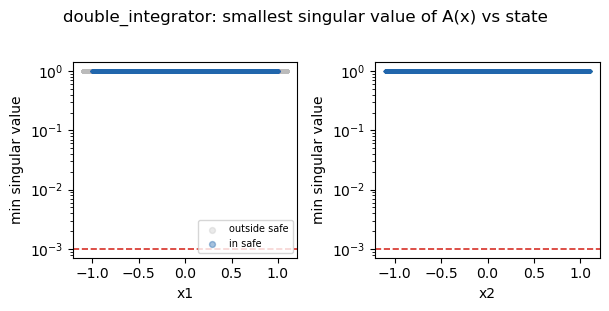

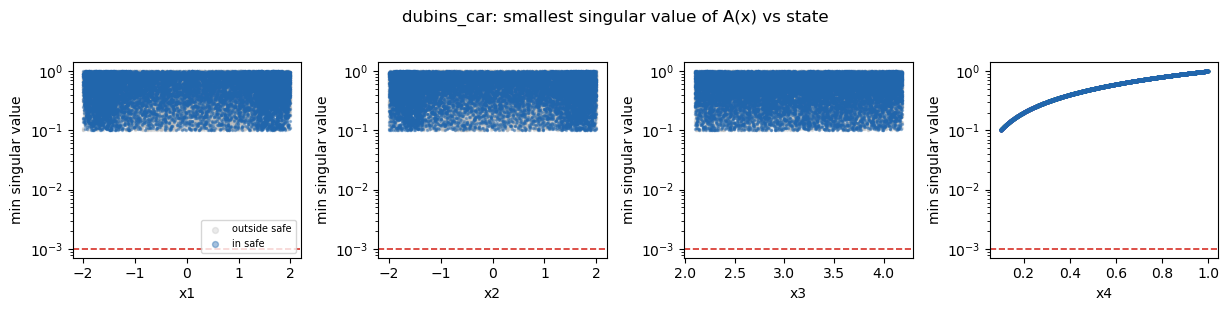

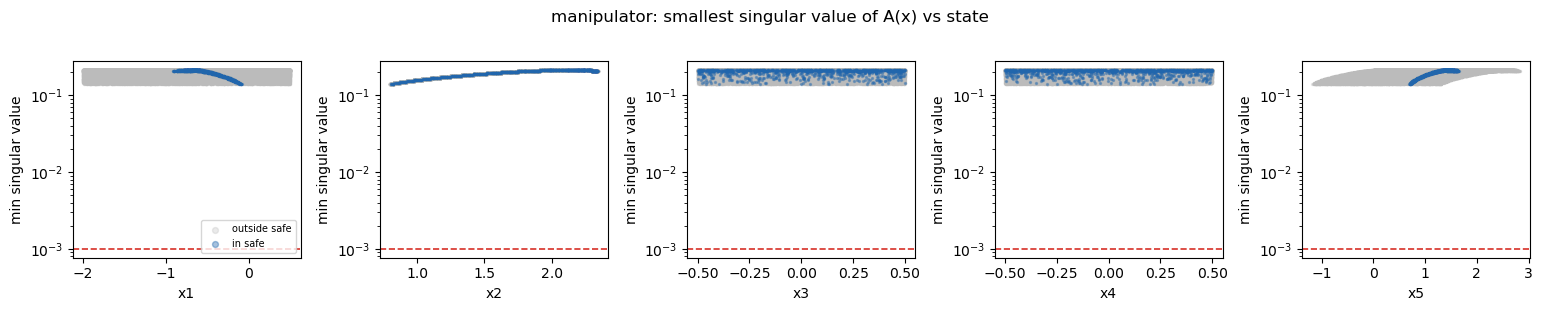

In [3]:
for name, df in frames.items():
    state_cols = [c for c in df.columns if c.startswith("x")]
    k = len(state_cols)
    fig, axes = plt.subplots(1, k, figsize=(3.1 * k, 3.0), squeeze=False)
    for ax, c in zip(axes[0], state_cols):
        m = df.in_safe == 1
        ax.scatter(
            df.loc[~m, c],
            df.loc[~m, "min_sv"],
            s=2,
            c="#bbbbbb",
            alpha=0.3,
            label="outside safe",
        )
        ax.scatter(
            df.loc[m, c],
            df.loc[m, "min_sv"],
            s=2,
            c="#2166ac",
            alpha=0.4,
            label="in safe",
        )
        ax.axhline(TOL_SV, color="#d73027", lw=1.2, ls="--")
        ax.set_yscale("log")
        ax.set_xlabel(c)
        ax.set_ylabel("min singular value")
    axes[0][0].legend(fontsize=7, markerscale=3, loc="lower right")
    fig.suptitle(f"{name}: smallest singular value of A(x) vs state", y=1.02)
    fig.tight_layout()
    plt.show()

## 3. Distribution of conditioning over the safe set


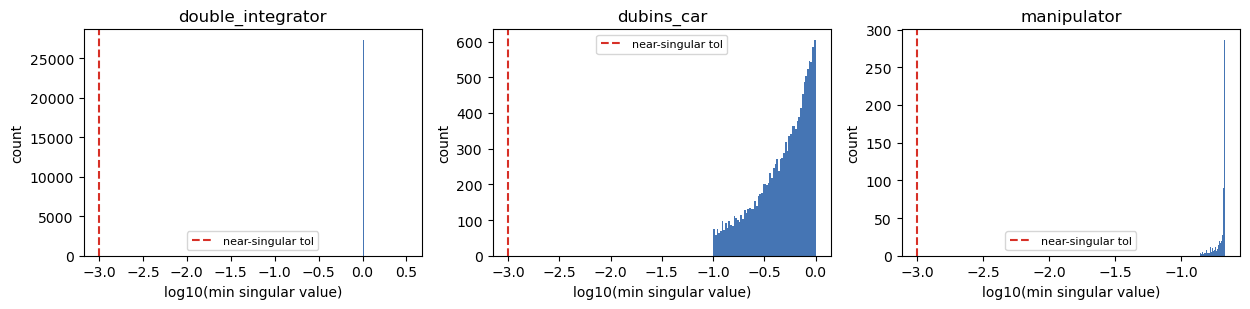

In [4]:
fig, axes = plt.subplots(
    1, len(frames), figsize=(4.2 * len(frames), 3.2), squeeze=False
)
for ax, (name, df) in zip(axes[0], frames.items()):
    region = df[df.in_safe == 1]
    region = region if len(region) else df
    vals = region.min_sv.replace(0, np.nan).dropna()
    ax.hist(np.log10(vals), bins=60, color="#4575b4")
    ax.axvline(
        np.log10(TOL_SV), color="#d73027", lw=1.5, ls="--", label="near-singular tol"
    )
    ax.set_xlabel("log10(min singular value)")
    ax.set_ylabel("count")
    ax.set_title(name)
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()